* **mpg**: 연비 (1갤런당 주행 거리)
* **cyl**: 실린더 개수
* **disp**: 배기량 (입방인치, cu.in.)
* **hp**: 최대 마력
* **drat**: 후륜 차축 기어비
* **wt**: 차량 무게 (1,000lb 단위)
* **qsec**: 1/4마일(약 402m) 주행 시간
* **vs**: 엔진 형태 (0 = V형, 1 = 직렬)
* **am**: 변속기 종류 (0 = 자동, 1 = 수동)
* **gear**: 전진 기어 수
* **carb**: 기화기 개수


### 다음 DataFrame methods을 사용해서 데이터셋의 결과를 출력하세요.

In [13]:
import pandas as pd

df = pd.read_csv('mtcars.csv')

# 1. 처음 5개 행 출력
print("1. head, tail")
print(df.head())
# 2. 마지막 5개 행 출력
print(df.tail())
# 3. 데이터 크기 (행, 열)
print("2. 데이터 크기:", df.shape)
# 4. 데이터 개수 (row count)
print("3. 행 개수:", df.shape[0])
# 5. 컬럼 이름 출력
df.rename(columns={"Unnamed: 0": "model"}, inplace=True)
print("4. 컬럼 이름:", df.columns)

print("5. 데이터 info:")
print(df.info())
print("데이터 타입:", df.dtypes)

print("6. 데이터 통계 요약:")
print(df.describe())



1. head, tail
          Unnamed: 0   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  
        Unnamed: 0   mpg  cyl   disp   hp  drat     wt  qsec  vs  am  gear  \
27    Lotus Europa  30.4    4   95.1  113  3.77  1.513  16.9   1   1     5   
28  Ford Pantera L  15.8    8  351.0  264  4.22  3.170  14.5   0   1     5   
29    Ferrari Dino  19.7    6  145.0  175  3.62  2.770  15.5   0   1     5   
30   Maserati Bora  15.0    8  301.0  335  3.54  3.570  14.6   0   1     5   
31      Volvo 142E  21.4    4  121.0  109  4.11  

### gear, transmission features에는 각각 몇가지 값이 있는지를 출력하세요.


| 컬럼명  | 의미                                    |
| ---- | ------------------------------------- |
| `am` | **Transmission** (변속기 종류)             |
| 값    | `0 = automatic(자동)`, `1 = manual(수동)` |


In [14]:
print(df["gear"].unique())
print(df["am"].unique())

print(df["gear"].nunique())
print(df["am"].nunique())

[4 3 5]
[1 0]
3
2


### gear와 transmission의 경우의 수 조합별로 나누고 각 조합에 몇개의 차량이 있는지를 알아내세요.
- 먼저 결과값을 화면에 출력하세요.
- 결과값을 바 그래프로 그리세요. 타이틀은 '# of Cars by Gear x Transmission'로, x축 레이블은 '(Gear, Auto Transmission)', y축 레이블은 '# of Cars'로 만드세요.

1) pandas.crosstab method를 사용하는 방법
am     0  1
gear       
3     15  0
4      4  8
5      0  5


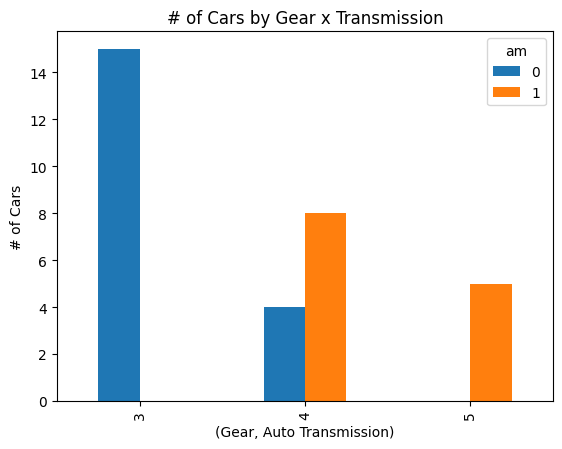

2) 사용하지 않는 방법
gear  am
3     0     15
4     0      4
      1      8
5     1      5
dtype: int64


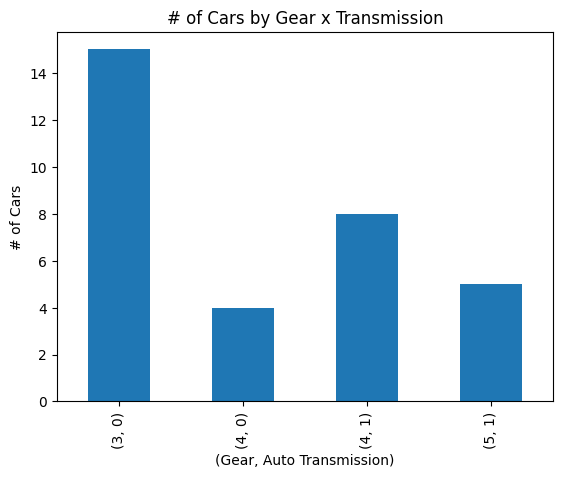

In [24]:
import matplotlib.pyplot as plt

# gear와 am(Transmission) 조합별 차량 개수
# 1) pandas.crosstab method를 사용하는 방법
gear_trans1 = pd.crosstab(df["gear"], df["am"])
print("1) pandas.crosstab method를 사용하는 방법")
print(gear_trans1)

gear_trans1.plot(kind='bar')
plt.title('# of Cars by Gear x Transmission')
plt.xlabel('(Gear, Auto Transmission)')
plt.ylabel('# of Cars')
plt.show()

# 2) 사용하지 않는 방법
gear_trans2 = df.groupby(["gear", "am"]).size()
print("2) 사용하지 않는 방법")
print(gear_trans2)

gear_trans2.plot(kind='bar')
plt.title('# of Cars by Gear x Transmission')
plt.xlabel('(Gear, Auto Transmission)')
plt.ylabel('# of Cars')
plt.show()

| 구분     | `groupby()`                   | `pd.crosstab()`                       |
| ------ | ----------------------------- | ------------------------------------- |
| 목적     | 데이터를 그룹으로 묶어 다양한 통계 계산        | 두 개 이상의 범주형 변수의 빈도(교차표) 계산            |
| 반환 형태  | Series 또는 DataFrame           | 교차표(DataFrame)                        |
| 가능한 연산 | 개수, 평균, 합계, 최댓값, 최솟값 등 다양한 집계 | 기본적으로 빈도(개수), 비율(normalize) 계산        |
| 사용 예시  | "기어별 평균 연비는?" "기어별 평균 마력은?"   | "기어와 변속기 조합별 차량 수는?" "성별과 합격 여부 인원은?" |


### 데이터셋에 포함된 모든 features의 히스토그램을 그리세요.
- 그래프 타이틀은 "Histograms of Variables"로 하세요.
- 최대한 잘 보이도록 그래프들을 배치하세요.

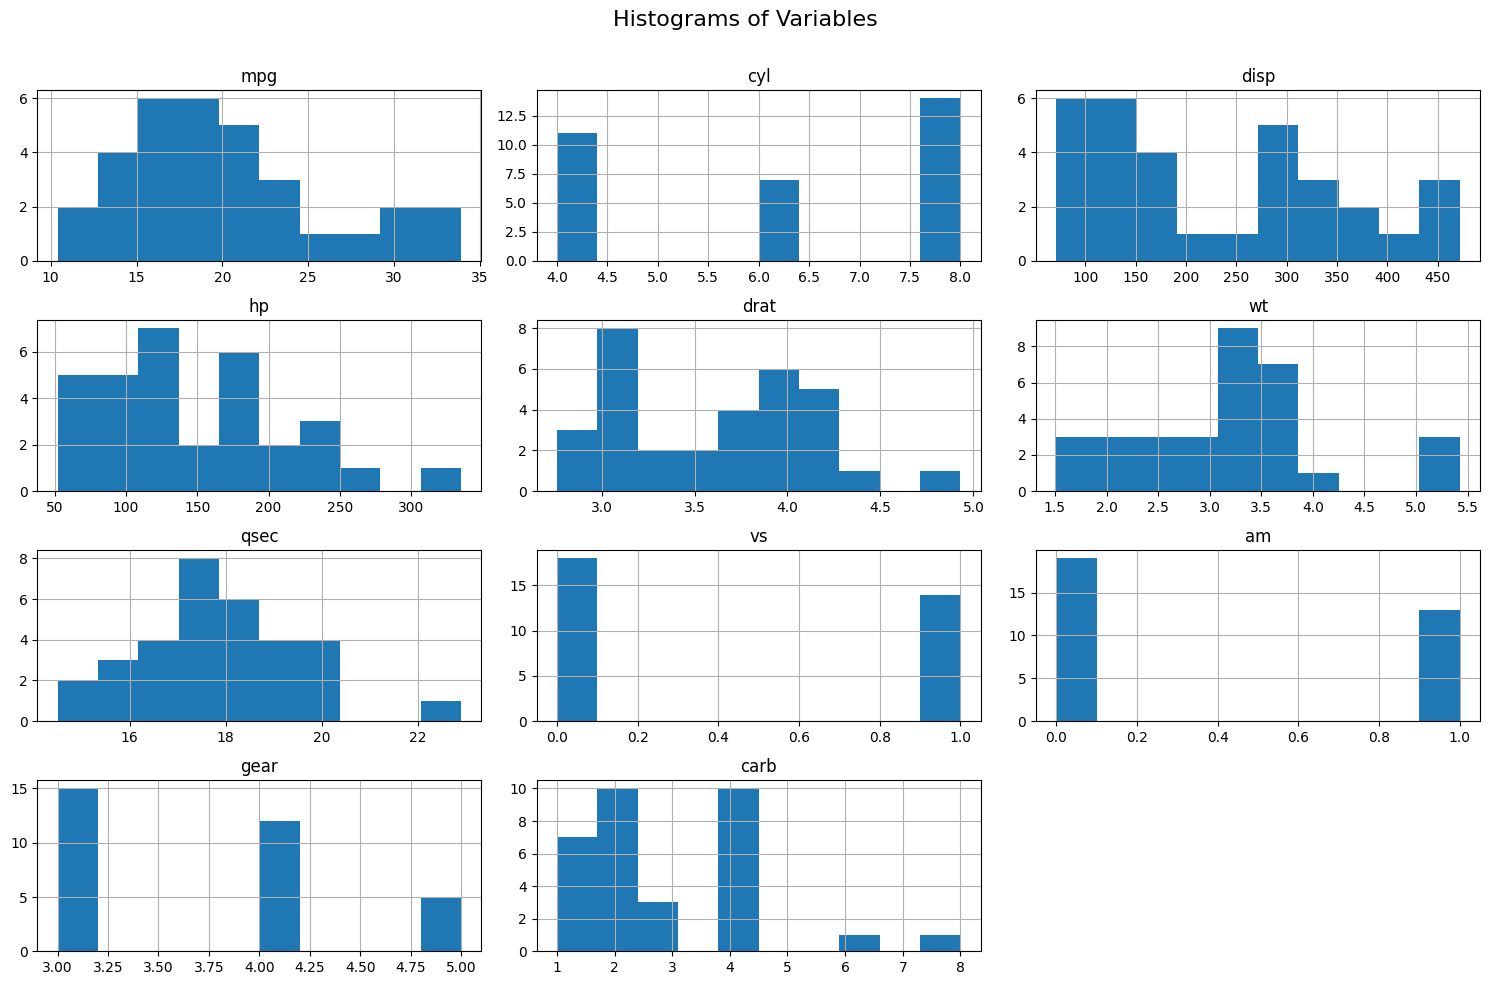

In [30]:
# 모든 feature의 히스토그램
df.hist(figsize=(15, 10), bins=10)

# 전체 제목
plt.suptitle("Histograms of Variables", fontsize=16)

# 그래프 간격 자동 조정
plt.tight_layout()

# suptitle과 그래프가 겹치지 않도록 조정
plt.subplots_adjust(top=0.90)

plt.show()

### Cylinder와 HorsePower 간의 상관 관계를 알아보기 위해 scatter 차트를 그리세요.
- 그래프 타이틀은 "Cylinder vs Horse Power"로 하세요.


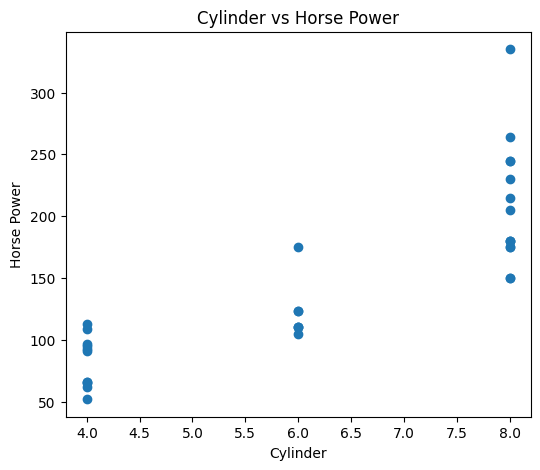

In [31]:
# Scatter Plot
plt.figure(figsize=(6, 5))
plt.scatter(df["cyl"], df["hp"])

# 제목 및 축 레이블
plt.title("Cylinder vs Horse Power")
plt.xlabel("Cylinder")
plt.ylabel("Horse Power")

plt.show()

### MPG와 HorsePower 간의 상관 관계를 알아보기 위해 scatter 차트를 그리세요.
- 그래프 타이틀은 "MPG vs Horse Power"로 하세요.


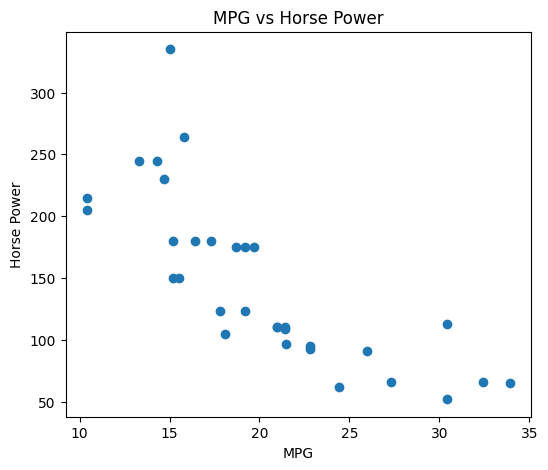

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(df["mpg"], df["hp"])

plt.title("MPG vs Horse Power")
plt.xlabel("MPG")
plt.ylabel("Horse Power")

plt.show()

### 각 변수들 간의 상관 관계를 알아 보기 위해 상관계수를 구하는 표를 출력하세요.

In [33]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

           mpg       cyl      disp        hp      drat        wt      qsec  \
mpg   1.000000 -0.852162 -0.847551 -0.776168  0.681172 -0.867659  0.418684   
cyl  -0.852162  1.000000  0.902033  0.832447 -0.699938  0.782496 -0.591242   
disp -0.847551  0.902033  1.000000  0.790949 -0.710214  0.887980 -0.433698   
hp   -0.776168  0.832447  0.790949  1.000000 -0.448759  0.658748 -0.708223   
drat  0.681172 -0.699938 -0.710214 -0.448759  1.000000 -0.712441  0.091205   
wt   -0.867659  0.782496  0.887980  0.658748 -0.712441  1.000000 -0.174716   
qsec  0.418684 -0.591242 -0.433698 -0.708223  0.091205 -0.174716  1.000000   
vs    0.664039 -0.810812 -0.710416 -0.723097  0.440278 -0.554916  0.744535   
am    0.599832 -0.522607 -0.591227 -0.243204  0.712711 -0.692495 -0.229861   
gear  0.480285 -0.492687 -0.555569 -0.125704  0.699610 -0.583287 -0.212682   
carb -0.550925  0.526988  0.394977  0.749812 -0.090790  0.427606 -0.656249   

            vs        am      gear      carb  
mpg   0.664039  